In [1]:
%reload_ext autoreload 
%autoreload 2 

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

sys.path.append(os.path.abspath('..'))

# load files
from src import forces, integrators, analysis

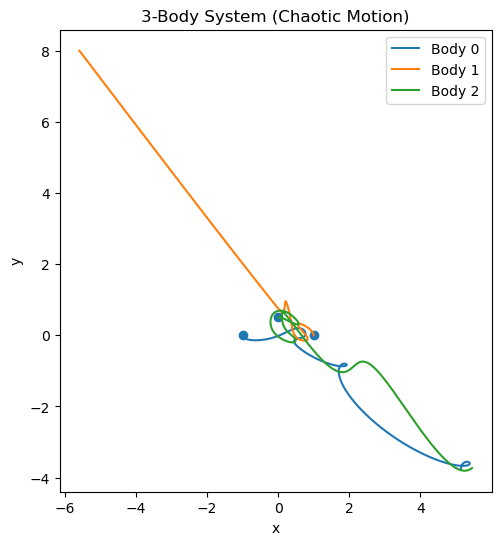

In [3]:
G = 1.0

m = np.array([1.0, 1.0, 1.0])

x = np.array([
    [-1.0, 0.0, 0.0],
    [ 1.0, 0.0, 0.0],
    [ 0.0, 0.5, 0.0]
])

v = np.array([
    [ 0.0, -0.3, 0.0],
    [ 0.0,  0.3, 0.0],
    [ 0.5,  0.0, 0.0]
])

x_3 = x.copy()
v_3 = v.copy()

traj_3 = []

dt = 0.001
nsteps = 10000

for step in range(nsteps):
    x_3, v_3 = integrators.step_leapfrog(x_3, v_3, m, dt)
    traj_3.append(x_3.copy())

traj_3 = np.array(traj_3)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for i in range(3):
    plt.plot(traj_3[:,i,0], traj_3[:,i,1], label=f"Body {i}")

plt.scatter(traj_3[0,:,0], traj_3[0,:,1], marker="o")  # starting points

plt.gca().set_aspect('equal')
plt.legend()
plt.title("3-Body System (Chaotic Motion)")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

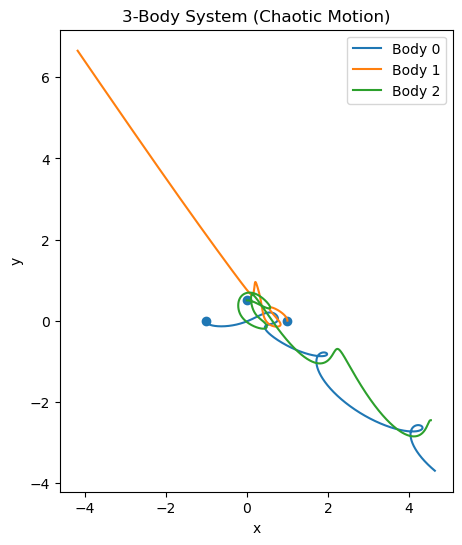

In [4]:
x2 = x.copy()
x2[2,0] += 1e-5   # tiny perturbation

v2 = v.copy()

traj2_3 = []

dt = 0.001
nsteps = 10000

for step in range(nsteps):
    x2, v2 = integrators.step_leapfrog(x2, v2, m, dt)
    traj2_3.append(x2.copy())

traj2_3 = np.array(traj2_3)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for i in range(3):
    plt.plot(traj2_3[:,i,0], traj2_3[:,i,1], label=f"Body {i}")

plt.scatter(traj2_3[0,:,0], traj2_3[0,:,1], marker="o")  # starting points

plt.gca().set_aspect('equal')
plt.legend()
plt.title("3-Body System (Chaotic Motion)")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

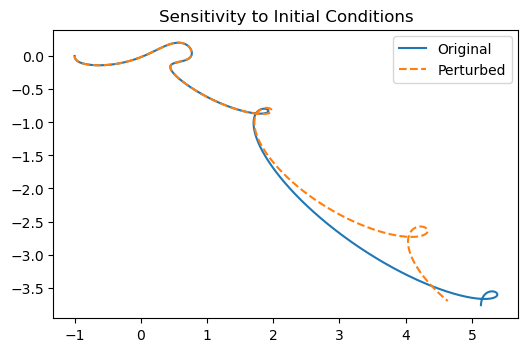

In [5]:
plt.figure(figsize=(6,6))

plt.plot(traj_3[:,0,0], traj_3[:,0,1], label="Original")
plt.plot(traj2_3[:,0,0], traj2_3[:,0,1], linestyle="--", label="Perturbed")

plt.legend()
plt.title("Sensitivity to Initial Conditions")

plt.gca().set_aspect('equal')
plt.show()

In [4]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython import display

fig, ax = plt.subplots(figsize=(6,6))

def animate(i):
    ax.clear()

    colors = ['blue', 'orange', 'green']
    
    for j in range(3):
        trail_len = 200
        start = max(0, i - trail_len)
        ax.plot(traj_3[start:i, j, 0], traj_3[start:i, j, 1], color=colors[j])
        ax.scatter(traj_3[i, j, 0], traj_3[i, j, 1], color=colors[j])

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(f"Step {i}")

# skip frames to make it faster
ani = FuncAnimation(fig, animate, frames=range(0, len(traj_3), 20), interval=30)

video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)

plt.close()